In [ ]:
import sys

if "google.colab" in sys.modules:
    # If running in Google colab
    from google.colab import drive
    drive.mount('/content/drive')

    # Install necessary libraries
    !pip install pymatgen torch_geometric tqdm

    # Set project path
    csv_data = "/content/drive/MyDrive/DATA/Dataset.csv"
    cifs_path = "/content/drive/MyDrive/DATA/cifs/"

else:
    # If running locally
    csv_data = "DATA/Dataset.csv"
    cifs_path = "DATA/cifs/"

Mounted at /content/drive


In [ ]:
print("hello, world")


print("hello, world")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

from xgboost import XGBClassifier
import shap

np.random.seed(42)

# Load Data

In [ ]:
df = pd.read_csv(csv_data)

### Feature Engineering

In [ ]:
FEATURES = [
    'spacegroup_number',
    'number of atoms',
    'Band Gap',
    'a', 'b', 'c',
    'alpha', 'beta', 'gamma',
    'Z',
    'electronegativity'
]

TARGET = 'label'

df_model = df[FEATURES + [TARGET]].dropna().copy()

In [ ]:
X = df_model[FEATURES]
y = df_model[TARGET]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (9668, 12)
Target: (9668,)


### Stratified Split of Data (70% 15% 15%)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"{name}: {len(yy)} samples | TI ratio: {yy.mean():.3f}")

Train: 6767 samples | TI ratio: 0.462
Val: 1450 samples | TI ratio: 0.462
Test: 1451 samples | TI ratio: 0.462


# Random Forest Training

In [ ]:
# The model
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    min_samples_split=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# Model Evaluation
print("\nRANDOM FOREST")

from train_test_functions import evaluate_model

rf_train_prob = evaluate_model(rf, X_train, y_train, "Train")
rf_val_prob   = evaluate_model(rf, X_val, y_val, "Validation")
rf_test_prob  = evaluate_model(rf, X_test, y_test, "Test")


RANDOM FOREST

Train Performance:
Accuracy : 0.9359
F1-score : 0.9317
ROC-AUC  : 0.9903
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3638
           1       0.92      0.95      0.93      3129

    accuracy                           0.94      6767
   macro avg       0.94      0.94      0.94      6767
weighted avg       0.94      0.94      0.94      6767


Validation Performance:
Accuracy : 0.8510
F1-score : 0.8409
ROC-AUC  : 0.9249
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       780
           1       0.83      0.85      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance:
Accuracy : 0.8704
F1-score : 0.8607
ROC-AUC  : 0.9369
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       

RF Confunsion Matrix

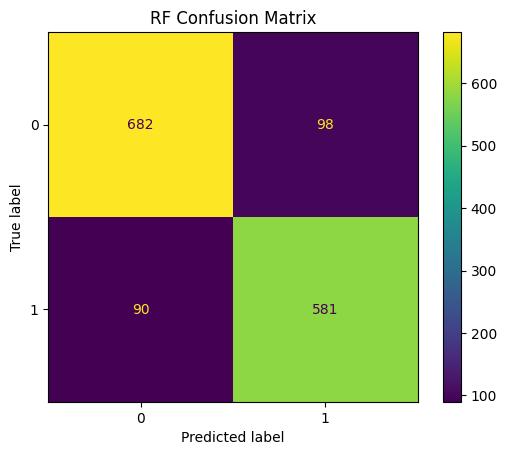

In [ ]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("RF Confusion Matrix")
plt.show()

# XGBoost Training

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=5,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
print("\nXGBoost")

xgb_train_prob = evaluate_model(xgb_model, X_train, y_train, "Train")
xgb_val_prob   = evaluate_model(xgb_model, X_val, y_val, "Validation")
xgb_test_prob  = evaluate_model(xgb_model, X_test, y_test, "Test")


XGBoost

Train Performance:
Accuracy : 0.9010
F1-score : 0.8949
ROC-AUC  : 0.9667
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      3638
           1       0.88      0.91      0.89      3129

    accuracy                           0.90      6767
   macro avg       0.90      0.90      0.90      6767
weighted avg       0.90      0.90      0.90      6767


Validation Performance:
Accuracy : 0.8517
F1-score : 0.8427
ROC-AUC  : 0.9264
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       780
           1       0.83      0.86      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance:
Accuracy : 0.8739
F1-score : 0.8641
ROC-AUC  : 0.9373
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       780
  

XGB Confunsion Matrix

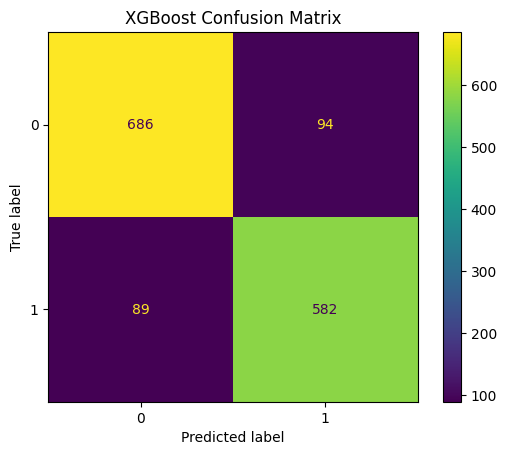

In [ ]:
cm = confusion_matrix(y_test, xgb_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

###RF & XGB ROC CURVES

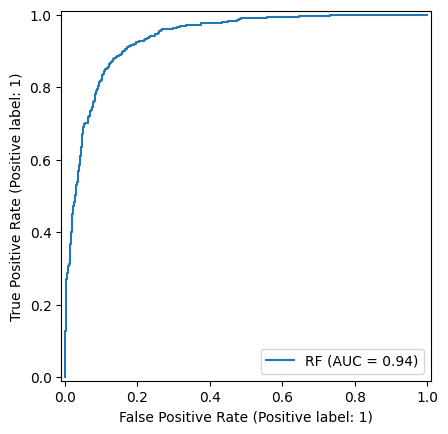

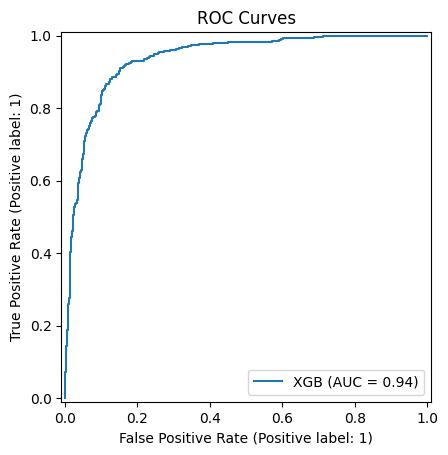

In [ ]:
RocCurveDisplay.from_predictions(y_test, rf_test_prob, name="RF")
RocCurveDisplay.from_predictions(y_test, xgb_test_prob, name="XGB")

plt.title("ROC Curves")
plt.show()

###SHAP INTERPRETABILITY

In [ ]:
#RF
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

In [ ]:
#XGB
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

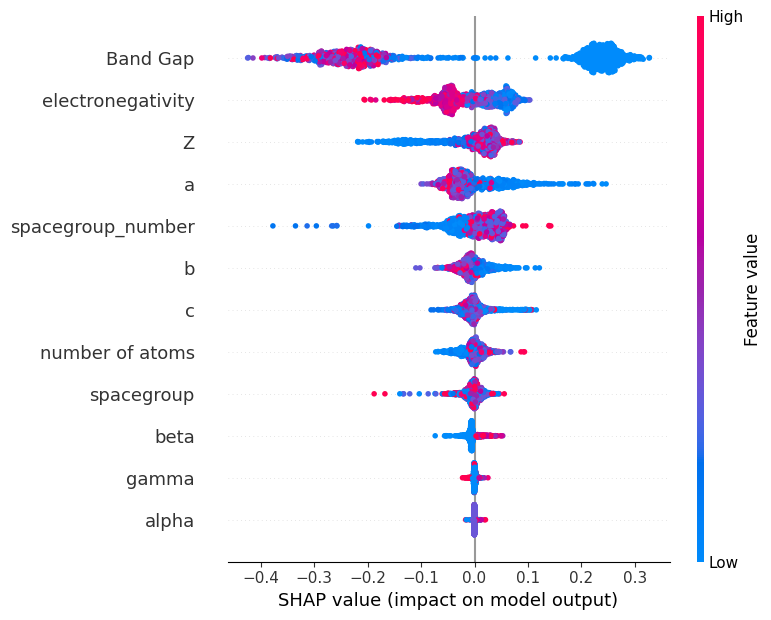

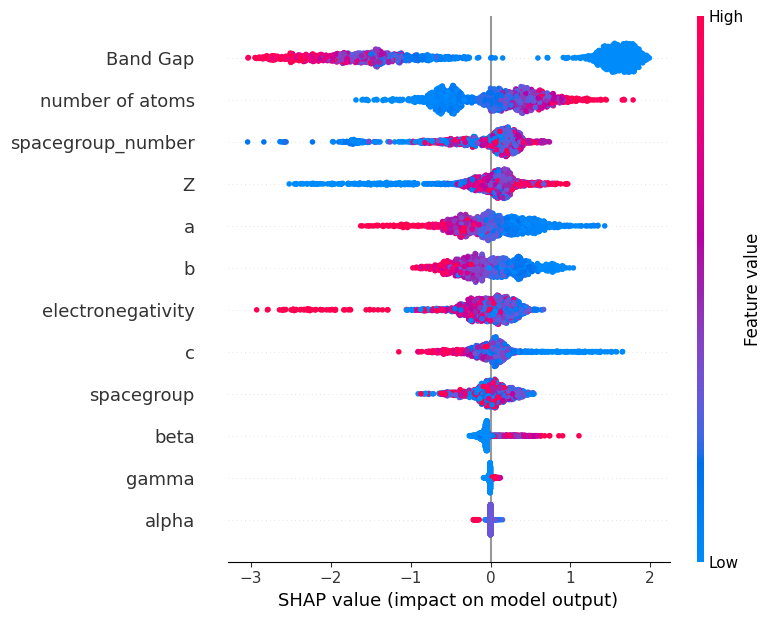

In [ ]:
#Beeswarm Plot
shap.summary_plot(shap_values_rf[:, :, 1], X_test)
shap.summary_plot(shap_values_xgb, X_test)

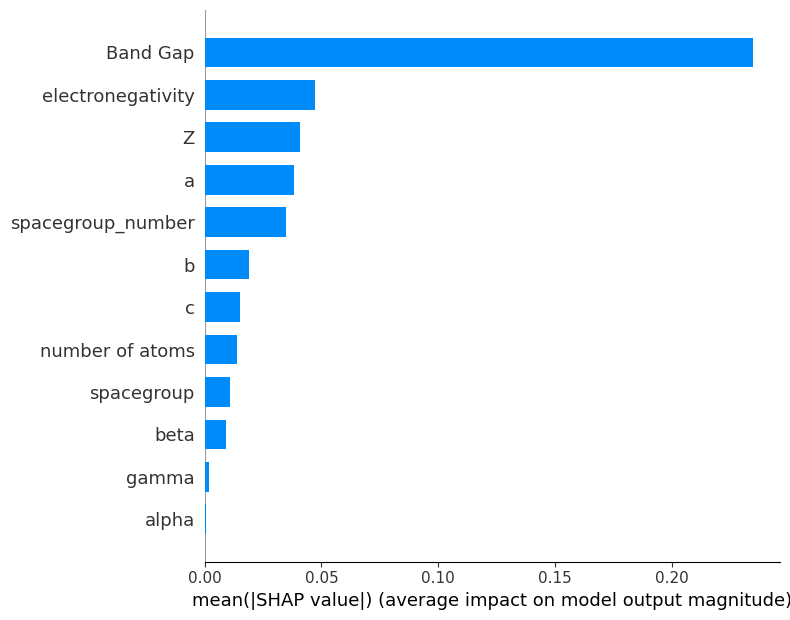

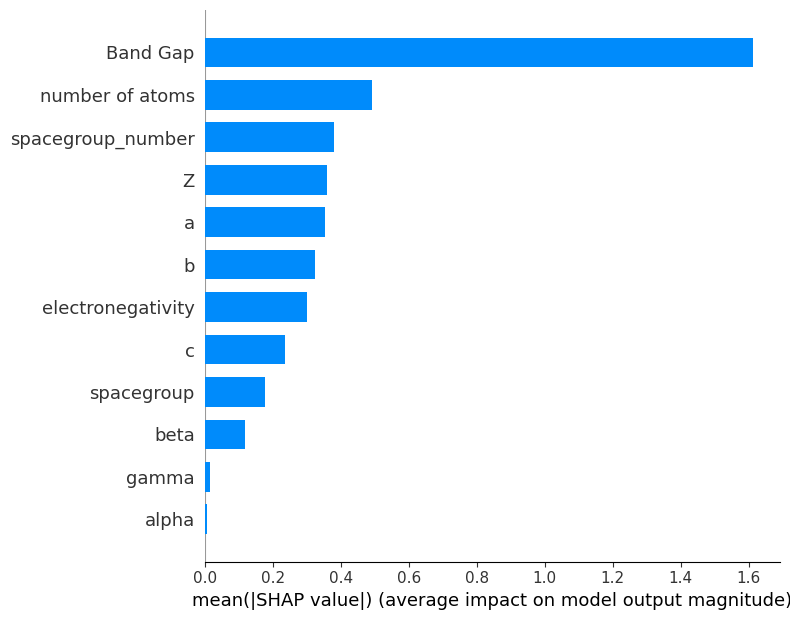

In [ ]:
#Bar PLot
shap.summary_plot(shap_values_rf[:, :, 1], X_test, plot_type="bar")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

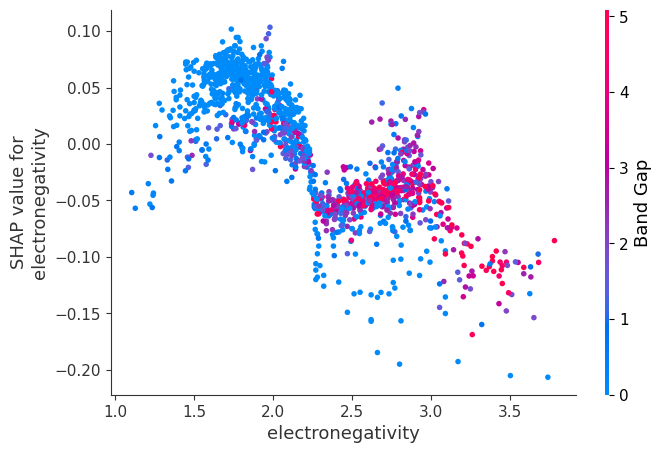

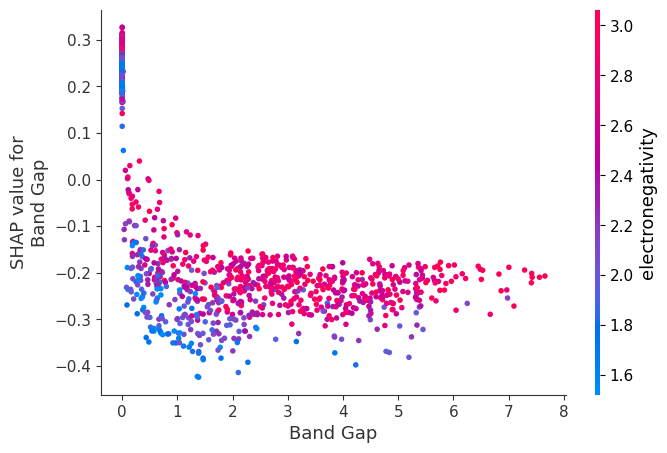

In [ ]:
#Dependance plots
import numpy as np

# Calculate feature importance for the positive class (index 1) across all samples
rf_importance = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
top_features = np.argsort(rf_importance)[-2:]

for i in top_features:
    # Use SHAP values for the positive class (index 1) for all samples
    shap.dependence_plot(X.columns[i], shap_values_rf[:, :, 1], X_test)

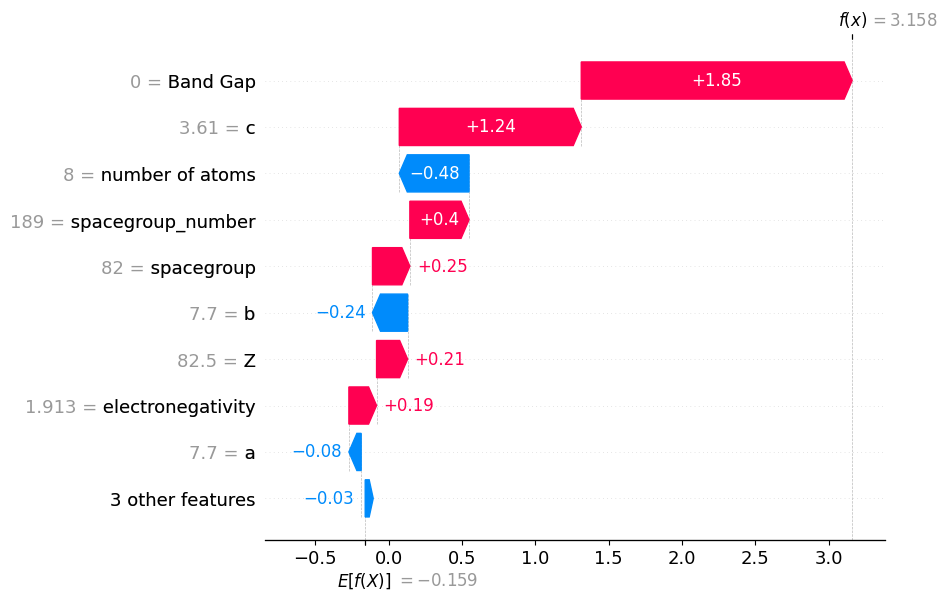

In [ ]:
#Waterfall PLot
shap.plots.waterfall(shap.Explanation(
    values=shap_values_xgb[0],
    base_values=explainer_xgb.expected_value,
    data=X_test.iloc[0]
))

In [ ]:
#Force PLot
shap.initjs()
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[0],
    X_test.iloc[0]
)